# 04 - Dynamic Linear Model 

The regression coefficients are allowed to vary over time, cast as a **Dynamic
Linear Model (DLM)**. The latent state
$\theta_t$ collects the time-varying coefficients; this is a **dynamic
regression**, i.e. a DLM with $F_t = (1\;\; x_t^\top)$ and $G_t = I_p$
(random-walk / local-level evolution of the state).

$$
\begin{aligned}
\theta_0 &\sim N_p(m_0, C_0), \\
Y_t &= F_t\,\theta_t + v_t, & v_t &\sim N(0, V), \\
\theta_t &= G_t\,\theta_{t-1} + w_t, & w_t &\sim N_p(0, W).
\end{aligned}
$$

Here $Y_t$ is the excess return, $F_t = (1,\, \mathrm{SP500}_t,\, \mathrm{UST10Y}_t,\,
\mathrm{fxvol}_t,\, \mathrm{TED}_t,\, \mathrm{VIX}_t)$ is the row of regressors,
$\theta_t \in \mathbb{R}^p$ ($p=6$) the coefficient vector, and $G_t = I_p$.

**Specification choices.** $m_0$ and $C_0$ are the full-sample OLS estimate and
its covariance. The observation variance $V$ is estimated by maximum likelihood.
The evolution covariance is calibrated per coefficient,
$W = \lambda \cdot \operatorname{diag}\!\big(\widehat{\operatorname{Var}}(\hat\theta_{\text{OLS}})\big)$,
so weakly-identified coefficients do not diverge; $\lambda$ sets the
signal-to-noise ratio $r = W/V$ (smaller $\lambda$ ⇒ smoother state).

## Kalman filter

Given $\theta_{t-1}\mid y_{1:t-1} \sim N_p(m_{t-1}, C_{t-1})$, the recursions are

$$
\begin{aligned}
\textbf{prediction:} \quad & a_t = G_t\,m_{t-1}, & R_t &= G_t\,C_{t-1}\,G_t^\top + W, \\
\textbf{forecast:} \quad & f_t = F_t\,a_t, & Q_t &= F_t\,R_t\,F_t^\top + V, \\
\textbf{innovation:} \quad & e_t = Y_t - f_t, & K_t &= R_t\,F_t^\top\,Q_t^{-1}, \\
\textbf{update:} \quad & m_t = a_t + K_t\,e_t, & C_t &= R_t - K_t\,Q_t\,K_t^\top.
\end{aligned}
$$

Filtering gives $\theta_t \mid y_{1:t} \sim N_p(m_t, C_t)$; the backward Kalman
smoother gives $\theta_t \mid y_{1:T}$. Below, `statsmodels` runs exactly these
recursions internally; the plotted paths are the smoothed means
$\mathbb{E}(\theta_t \mid y_{1:T})$ with $\pm 2$ standard-deviation bands.

## Setup

In [1]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

CURRENCIES = ["CHF", "EUR", "GBP", "JPY"]
RATE = {"CHF": "CHF_3M", "EUR": "EUR_3M", "GBP": "GBP_3M", "JPY": "JPY_3M"}
REGRESSORS = ["SP500", "UST10Y", "fxvol", "TED", "VIX"]
TERMS = ["const"] + REGRESSORS
LAMBDA = 1e-3          # signal-to-noise r = W/V; larger => more time variation

## Load and construct variables

Identical construction to notebooks 02-03.

In [2]:
levels = pd.read_csv(Path("..") / "data" / "levels.csv",
                     index_col="date", parse_dates=True)

fx = levels[CURRENCIES].dropna()
appreciation = np.log(fx).diff()
sp500_d = np.log(levels["SP500"]).diff().rename("SP500")
vix_d = np.log(levels["VIX"]).diff().rename("VIX")
ust10y_d = levels["UST10Y"].diff().rename("UST10Y")
ted_d = ((levels["US_3M"] - levels["TBILL_3M"]) / 360).rename("TED")
# interbank rates are % p.a.; /100/360 gives the daily decimal carry
interest_diff = pd.DataFrame(
    {cur: (levels[RATE[cur]] - levels["US_3M"]) / 100 / 360 for cur in CURRENCIES})
excess = appreciation + interest_diff
realized = np.log(appreciation.rolling(30).std())
fx_vol = pd.DataFrame(
    {cur: realized[[o for o in CURRENCIES if o != cur]].mean(axis=1)
     for cur in CURRENCIES})
fx_vol = fx_vol - fx_vol.mean()   # centre log-vol so it does not offset the intercept

def model_frame(cur):
    return pd.concat([
        excess[cur].rename("excess"),
        sp500_d, ust10y_d, fx_vol[cur].rename("fxvol"), ted_d, vix_d,
    ], axis=1).dropna()

## The DLM

State-space model with the time-varying coefficient vector $\theta_t$ as the
state. Matrix names follow the course: $F$ = design, $G$ = transition,
$V$ = observation covariance, $W$ = state covariance, $(m_0, C_0)$ = initial state.

In [3]:
class DLM(sm.tsa.statespace.MLEModel):
    """Dynamic regression DLM: Y_t = F_t theta_t + v_t, theta_t = G theta_{t-1} + w_t."""

    def __init__(self, Y, F, W, m0, C0):
        p = F.shape[1]
        super().__init__(endog=Y, k_states=p, k_posdef=p)
        self["design"] = F.T.reshape(1, p, len(Y))   # F_t = (1, x_t')
        self["transition"] = np.eye(p)               # G_t = I_p  (random walk)
        self["selection"] = np.eye(p)
        self["state_cov"] = W                        # W
        self.initialize_known(m0, C0)                # theta_0 ~ N(m0, C0)

    @property
    def param_names(self):
        return ["V"]                                 # observation variance

    @property
    def start_params(self):
        return [np.var(self.endog)]

    def transform_params(self, u):
        return u ** 2

    def untransform_params(self, p):
        return np.sqrt(np.abs(p))

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self["obs_cov", 0, 0] = params[0]            # V


def fit_dlm(cur):
    df = model_frame(cur)
    Y = df["excess"].values
    F = np.column_stack([np.ones(len(df))] + [df[r].values for r in REGRESSORS])

    ols = sm.OLS(Y, F).fit()
    C0 = ols.mse_resid * np.linalg.inv(F.T @ F)      # OLS coefficient covariance
    W = LAMBDA * np.diag(np.diag(C0))                # calibrated evolution covariance

    # BFGS may warn 'failed to converge': the likelihood in V is flat at
    # machine precision near the optimum; the estimate and the smoothed
    # states are unchanged under maxiter=500, so the warning is spurious.
    res = DLM(Y, F, W, ols.params, C0).fit(disp=False)
    theta = pd.DataFrame(res.smoothed_state.T, index=df.index, columns=TERMS)
    sd = pd.DataFrame(
        np.sqrt(np.diagonal(res.smoothed_state_cov, axis1=0, axis2=1)),
        index=df.index, columns=TERMS)
    return theta, sd, ols.params

dlm = {cur: fit_dlm(cur) for cur in CURRENCIES}

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Time-varying fx-volatility coefficient

Smoothed path $\mathbb{E}(\theta_{t,\mathrm{fxvol}} \mid y_{1:T})$ with $\pm 2$ SD
band, the full-sample OLS value (dashed grey), and the Bai-Perron break dates from
notebook 03 (dotted red).

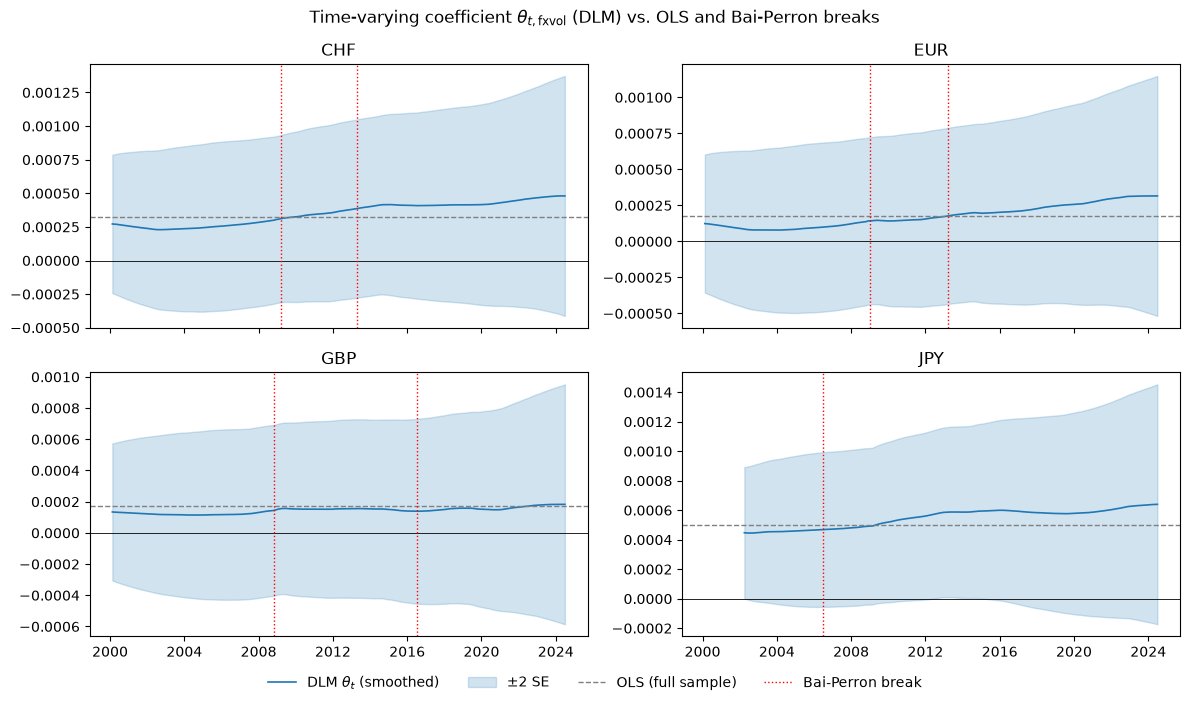

In [4]:
bp_path = Path("..") / "data" / "break_dates.csv"
bp = {}
if bp_path.exists():
    raw = pd.read_csv(bp_path, index_col=0)["break_dates"]
    bp = {cur: [pd.Timestamp(d) for d in ast.literal_eval(raw[cur])] for cur in raw.index}

COEF = "fxvol"
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, cur in zip(axes.ravel(), CURRENCIES):
    theta, sd, ols = dlm[cur]
    ax.plot(theta.index, theta[COEF], color="C0", lw=1.2, label=r"DLM $\theta_t$ (smoothed)")
    ax.fill_between(theta.index, theta[COEF] - 2 * sd[COEF], theta[COEF] + 2 * sd[COEF],
                    color="C0", alpha=0.2, label=r"$\pm$2 SE")
    ax.axhline(ols[TERMS.index(COEF)], color="grey", ls="--", lw=1, label="OLS (full sample)")
    ax.axhline(0, color="black", lw=0.6)
    for j, d in enumerate(bp.get(cur, [])):
        ax.axvline(d, color="red", ls=":", lw=1,
                   label="Bai-Perron break" if j == 0 else None)
    ax.set_title(cur)

handles, labels = [], []
for ax in axes.ravel():
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l and l not in labels:
            handles.append(h); labels.append(l)
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.01))
fig.suptitle(r"Time-varying coefficient $\theta_{t,\mathrm{fxvol}}$ (DLM) vs. OLS and Bai-Perron breaks")
fig.tight_layout(rect=[0, 0.03, 1, 1])

FIG_DIR = Path("..") / "figures"
FIG_DIR.mkdir(exist_ok=True)
fig.savefig(FIG_DIR / "dlm_fxvol.png", dpi=300, bbox_inches="tight")
plt.show()

## All coefficients (per currency)

Every component of $\theta_t$, one figure per currency.

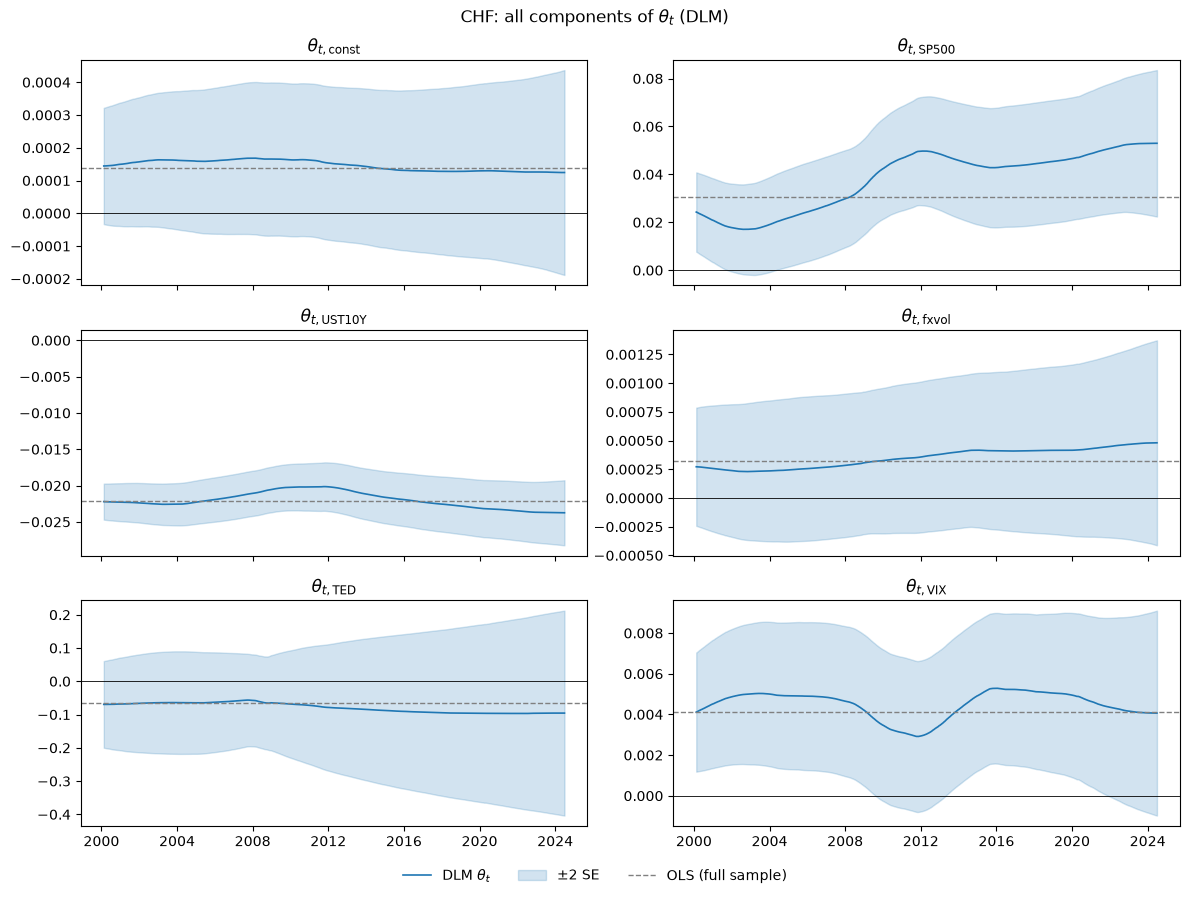

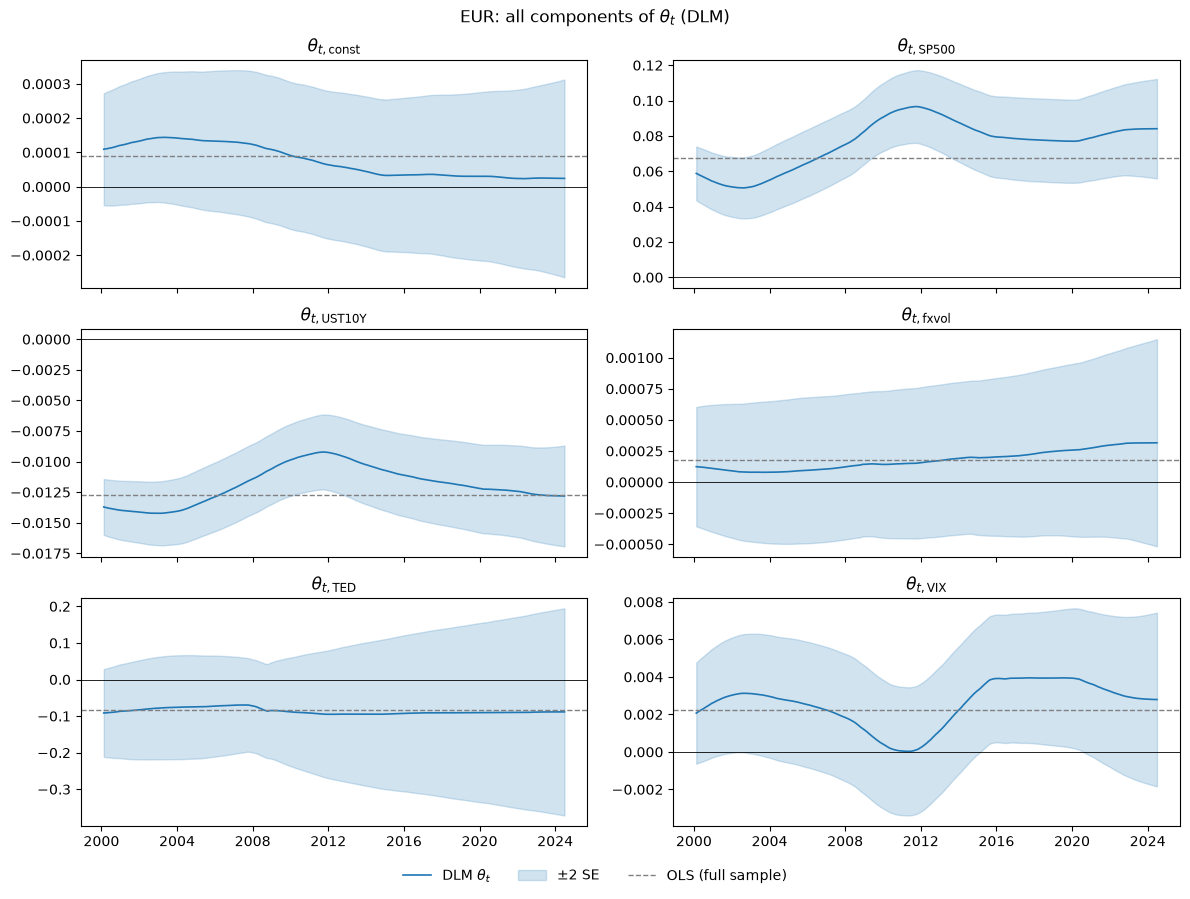

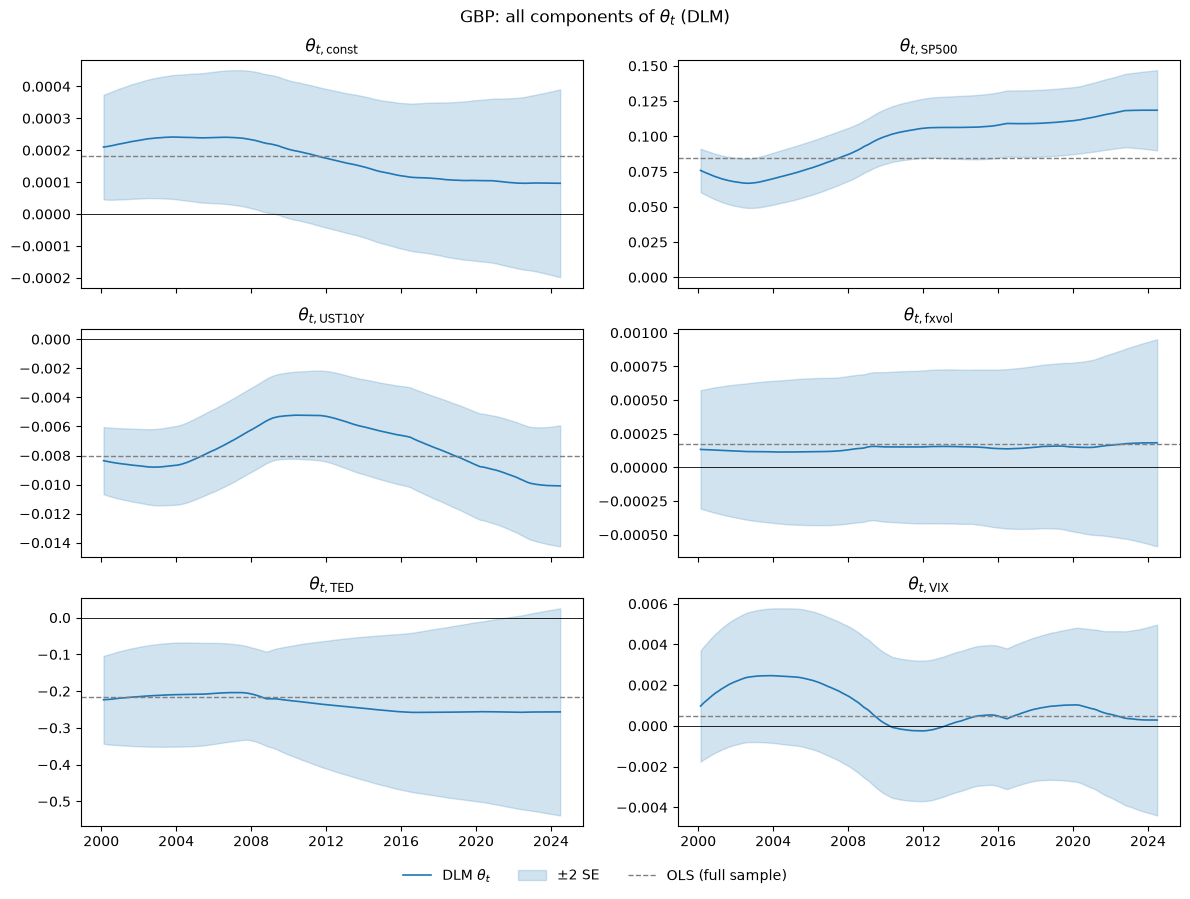

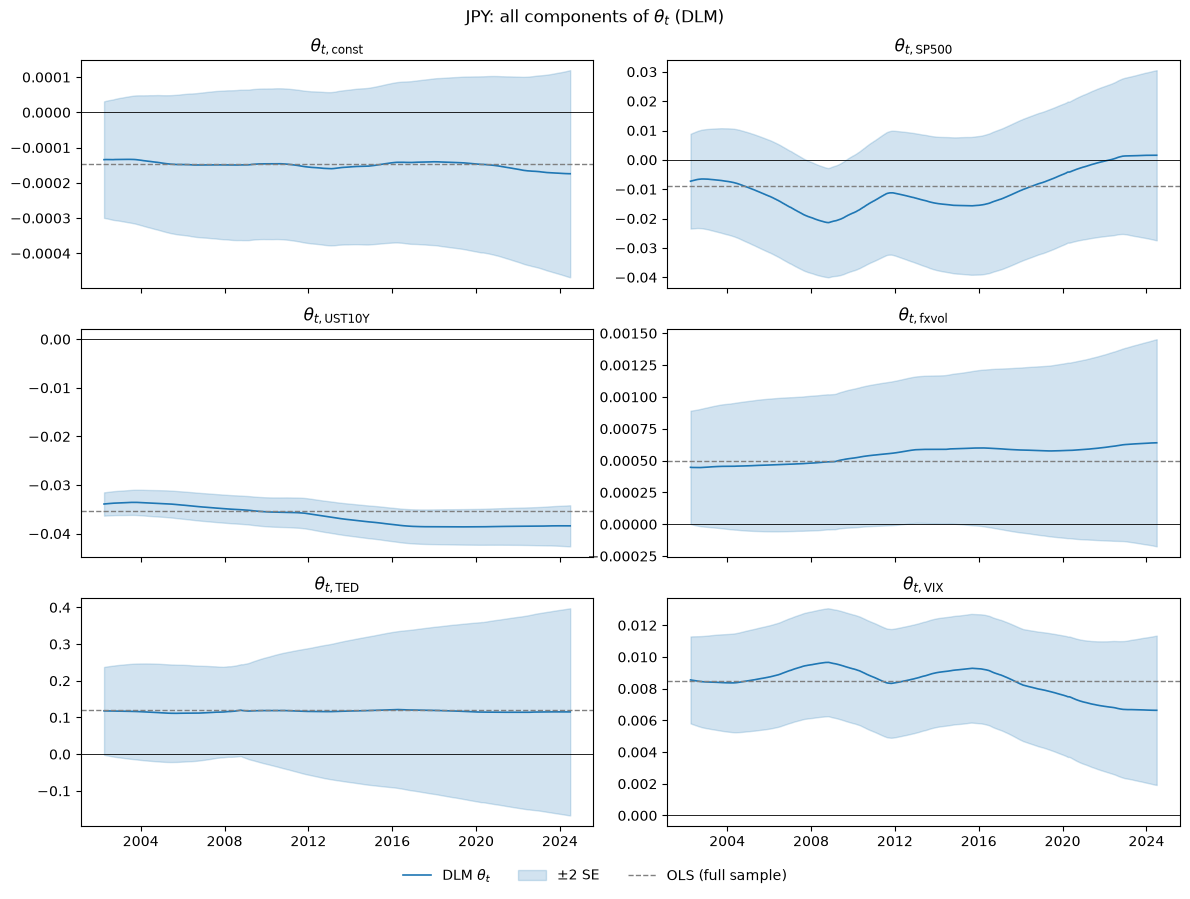

In [5]:
FIG_DIR.mkdir(exist_ok=True)
for cur in CURRENCIES:
    theta, sd, ols = dlm[cur]
    fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
    for ax, term in zip(axes.ravel(), TERMS):
        ax.plot(theta.index, theta[term], color="C0", lw=1.2, label=r"DLM $\theta_t$")
        ax.fill_between(theta.index, theta[term] - 2 * sd[term], theta[term] + 2 * sd[term],
                        color="C0", alpha=0.2, label=r"$\pm$2 SE")
        ax.axhline(ols[TERMS.index(term)], color="grey", ls="--", lw=1, label="OLS (full sample)")
        ax.axhline(0, color="black", lw=0.6)
        ax.set_title(fr"$\theta_{{t,\mathrm{{{term}}}}}$")
    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False,
               bbox_to_anchor=(0.5, -0.005))
    fig.suptitle(fr"{cur}: all components of $\theta_t$ (DLM)")
    fig.tight_layout(rect=[0, 0.03, 1, 1])
    fig.savefig(FIG_DIR / f"dlm_{cur}_all.png", dpi=300, bbox_inches="tight")
    plt.show()

## Standardised coefficients with break dates

Each smoothed coefficient expressed as its deviation from the full-sample OLS value in standard-error units, so all six panels share one axis. Points outside the $\pm2$ band are where the coefficient is meaningfully different from its constant value; the Bai-Perron break dates are overlaid (dotted).

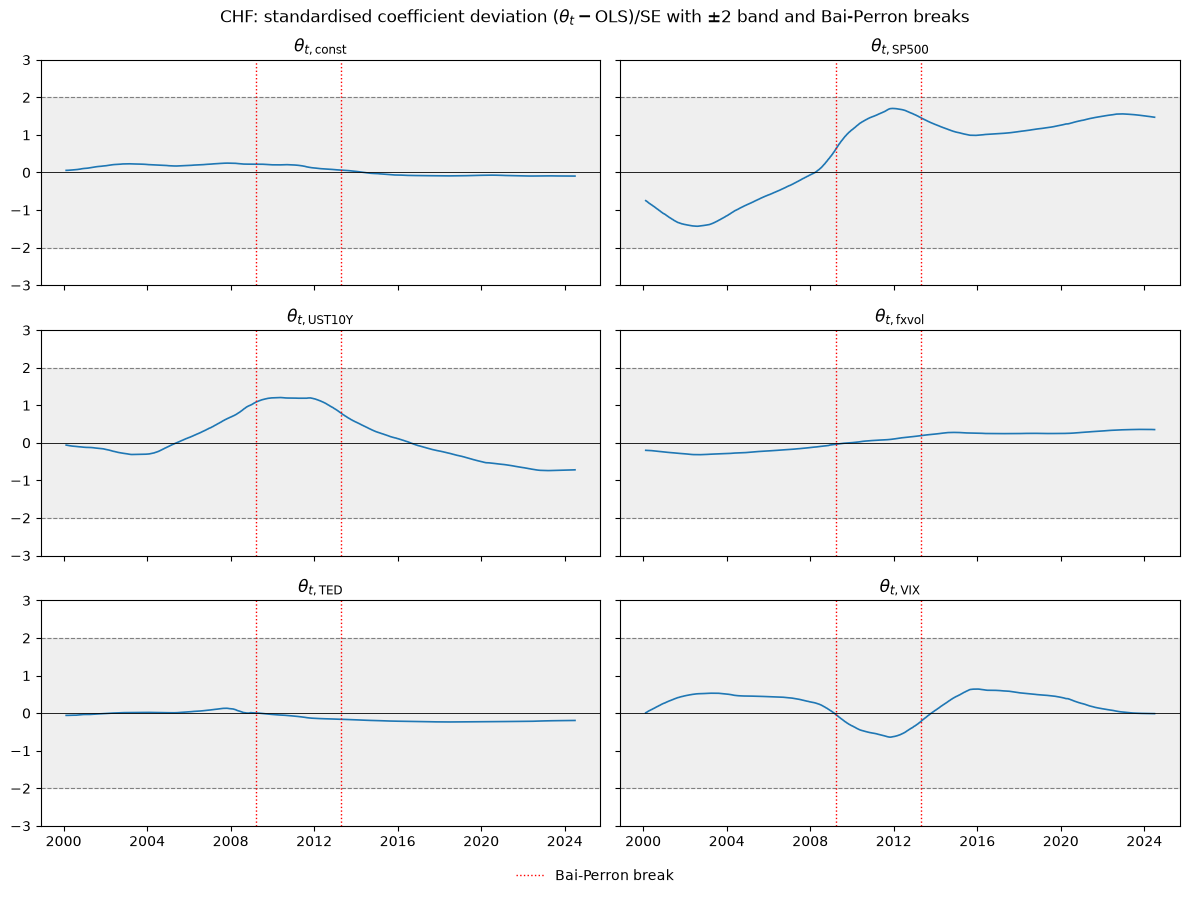

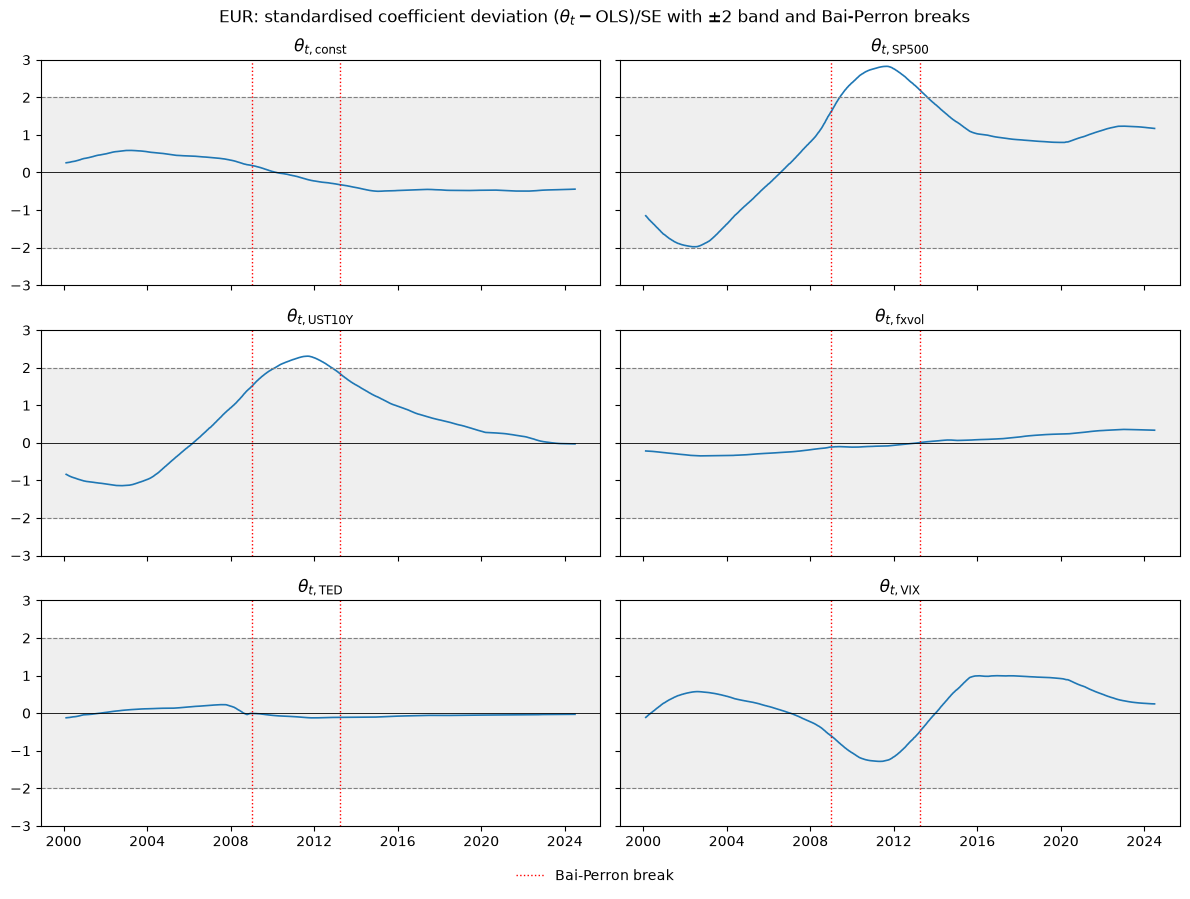

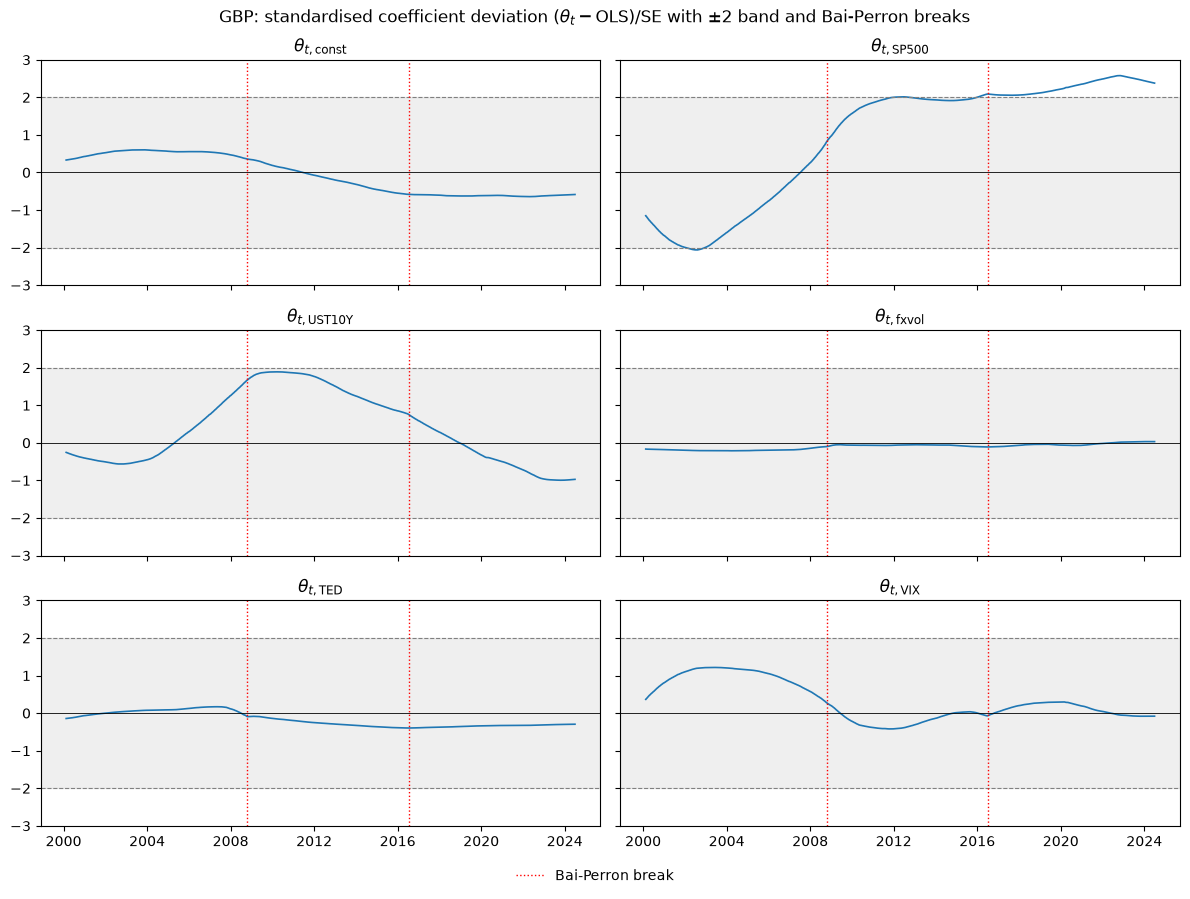

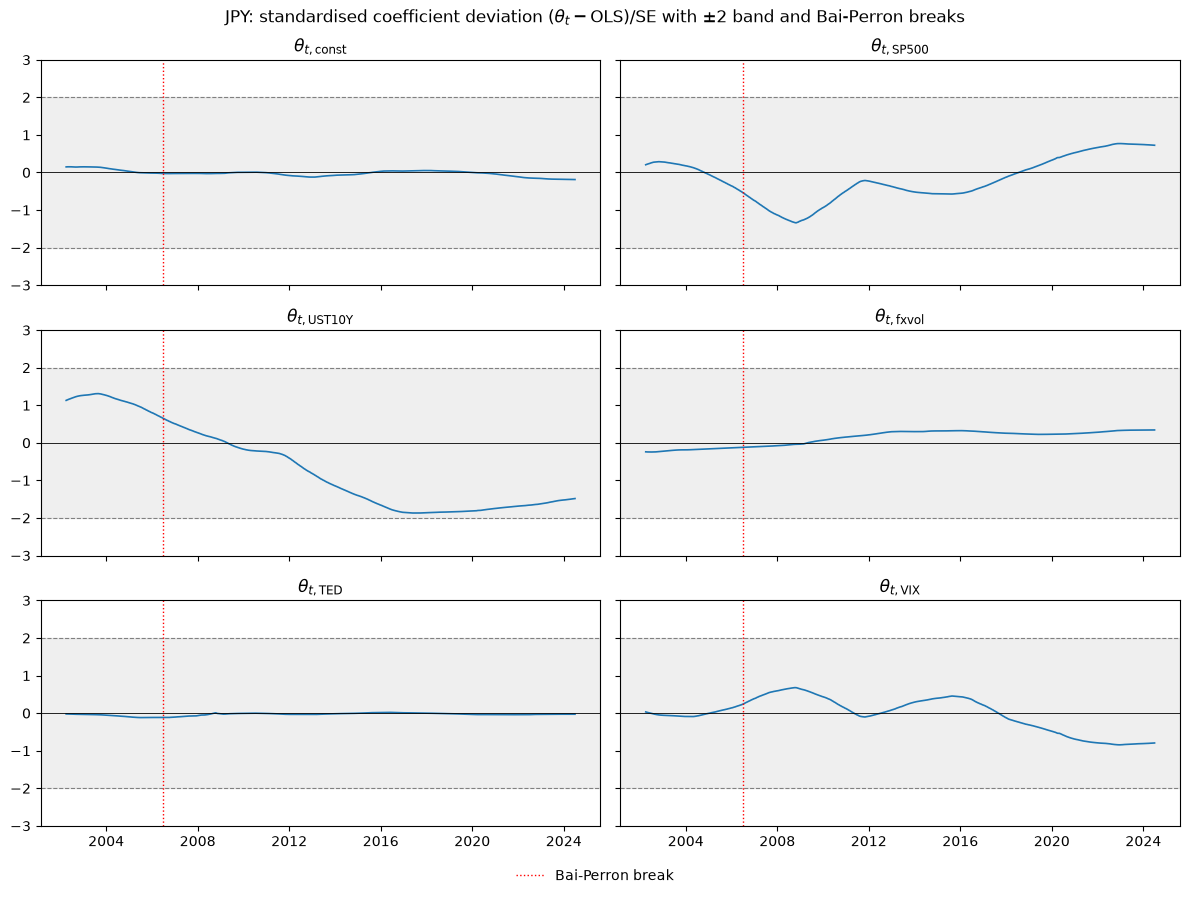

In [6]:
# Standardised view: deviation of each smoothed coefficient from its full-sample
# OLS value, in standard-error units, z_t = (theta_t - OLS)/SE_t. On this scale all
# six panels share one axis, and |z_t| > 2 marks where the coefficient's own 95%
# band excludes the constant OLS estimate -- i.e. meaningful time variation. The
# grey band is the +/-2 "indistinguishable from OLS" zone; Bai-Perron break dates
# are overlaid for direct comparison.
for cur in CURRENCIES:
    theta, sd, ols = dlm[cur]
    z = pd.DataFrame({term: (theta[term] - ols[TERMS.index(term)]) / sd[term]
                      for term in TERMS})
    ymax = min(8.0, max(3.0, float(np.ceil(z.abs().quantile(0.995).max()))))  # floor at 3 so the +/-2 band stays a sub-region with visible headroom
    fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True, sharey=True)
    for ax, term in zip(axes.ravel(), TERMS):
        ax.axhspan(-2, 2, color="grey", alpha=0.12)
        ax.plot(z.index, z[term], color="C0", lw=1.2)
        ax.axhline(0, color="black", lw=0.6)
        ax.axhline(2, color="grey", ls="--", lw=0.8)
        ax.axhline(-2, color="grey", ls="--", lw=0.8)
        for j, d in enumerate(bp.get(cur, [])):
            ax.axvline(d, color="red", ls=":", lw=1,
                       label="Bai-Perron break" if j == 0 else None)
        ax.set_ylim(-ymax, ymax)
        ax.set_title(fr"$\theta_{{t,\mathrm{{{term}}}}}$")
    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False,
                   bbox_to_anchor=(0.5, -0.005))
    fig.suptitle(fr"{cur}: standardised coefficient deviation "
                 fr"$(\theta_t-\mathrm{{OLS}})/\mathrm{{SE}}$ with $\pm2$ band and Bai-Perron breaks")
    fig.tight_layout(rect=[0, 0.03, 1, 1])
    fig.savefig(FIG_DIR / f"dlm_{cur}_std.png", dpi=300, bbox_inches="tight")
    plt.show()

## Joint deviation of the whole coefficient vector

The multivariate analogue of the per-coefficient $|z|>2$ view: one line per currency measuring how far the **entire** coefficient vector sits from its constant OLS value, via the Mahalanobis distance $D_t = (\theta_t-\mathrm{OLS})^\top C_t^{-1}(\theta_t-\mathrm{OLS})$ with $C_t$ the smoothed state covariance. Under constant coefficients $D_t\sim\chi^2_p$; the dashed line is the 95% threshold $\chi^2_6$. This is the DLM counterpart to a *joint* Bai-Perron break, each currency's break dates are overlaid in its own colour.

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


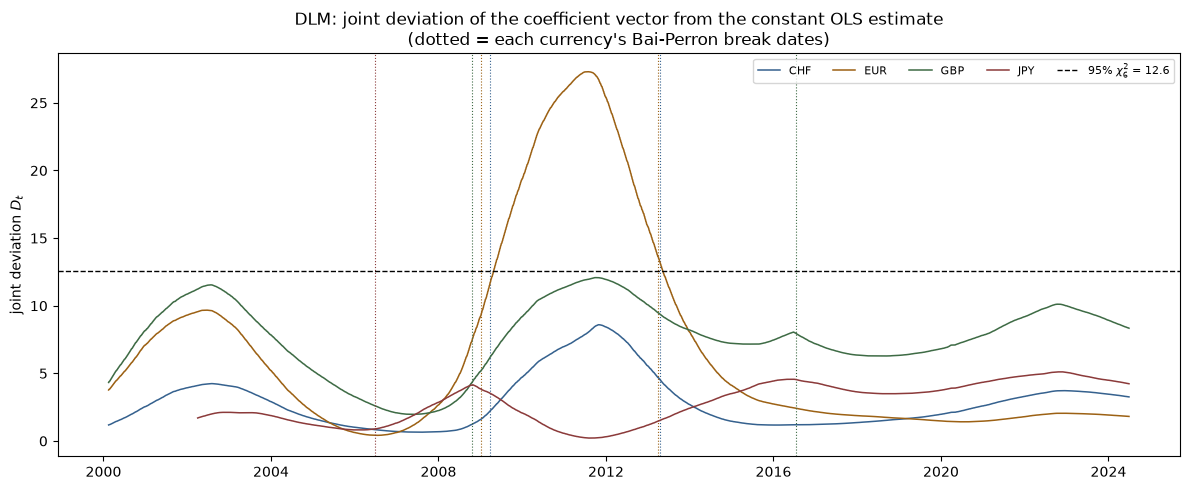

In [7]:
# Joint deviation of the whole coefficient vector from its constant OLS value.
# D_t = (theta_t - OLS)' C_t^{-1} (theta_t - OLS), C_t = smoothed state covariance.
# One line per currency: how far the ENTIRE relationship sits from constant.
# Under "coefficients constant", D_t ~ chi^2(p); dashed line = 95% chi^2(6) threshold.
# DLM counterpart to a joint Bai-Perron break; each currency's breaks overlaid.
from scipy.stats import chi2

def joint_deviation(cur):
    df = model_frame(cur)
    Y = df["excess"].values
    F = np.column_stack([np.ones(len(df))] + [df[r].values for r in REGRESSORS])
    ols = sm.OLS(Y, F).fit()
    C0 = ols.mse_resid * np.linalg.inv(F.T @ F)
    W = LAMBDA * np.diag(np.diag(C0))
    # BFGS may warn 'failed to converge': the likelihood in V is flat at
    # machine precision near the optimum; the estimate and the smoothed
    # states are unchanged under maxiter=500, so the warning is spurious.
    res = DLM(Y, F, W, ols.params, C0).fit(disp=False)
    theta, cov = res.smoothed_state, res.smoothed_state_cov      # (p, n), (p, p, n)
    d = theta - ols.params[:, None]
    D = np.array([d[:, t] @ np.linalg.solve(cov[:, :, t], d[:, t])
                  for t in range(theta.shape[1])])
    return pd.Series(D, index=df.index)

thr = chi2.ppf(0.95, df=len(TERMS))
joint = {cur: joint_deviation(cur) for cur in CURRENCIES}
colors = {"CHF": "#35618e", "EUR": "#9c6114", "GBP": "#3e6b45", "JPY": "#8b3a3a"}  # dark, muted

fig, ax = plt.subplots(figsize=(12, 5))
for cur in CURRENCIES:
    ax.plot(joint[cur].index, joint[cur], color=colors[cur], lw=1.1, label=cur)
    for d in bp.get(cur, []):
        ax.axvline(d, color=colors[cur], ls=":", lw=0.8)
ax.axhline(thr, color="black", ls="--", lw=1,
           label=fr"95% $\chi^2_{{{len(TERMS)}}}$ = {thr:.1f}")
ax.set_ylabel(r"joint deviation $D_t$")
ax.set_title("DLM: joint deviation of the coefficient vector from the constant OLS estimate\n"
             "(dotted = each currency's Bai-Perron break dates)")
ax.legend(ncol=5, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "dlm_joint_deviation.png", dpi=300, bbox_inches="tight")
plt.show()

## Persist

In [8]:
paths = pd.concat({cur: dlm[cur][0] for cur in CURRENCIES}, axis=1)
paths.columns.names = ["currency", "coefficient"]
out = Path("..") / "data" / "dlm_coefficients.csv"
paths.to_csv(out)
print(f"Saved smoothed state theta_t -> {out}")
print(f"Saved figures -> dlm_fxvol.png + dlm_<CUR>_all.png in {FIG_DIR}")

Saved smoothed state theta_t -> ../data/dlm_coefficients.csv
Saved figures -> dlm_fxvol.png + dlm_<CUR>_all.png in ../figures
